# Part 3 — Time Series: Forecasting the S&P 500 Index

**Dataset**: S&P 500 Index (daily updated)  
**Source**: https://www.kaggle.com/datasets/andrewmvd/sp-500-stocks/data  
**Target Variable**: S&P 500 index value (temporal/sequential)

This notebook implements classical (ARIMA) and ML (Lag Features + Random Forest)
forecasting methods, compares their performance, and discusses practical trade-offs.

In [4]:
!pip install statsmodels

## 1. Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load and Explore the Data

In [6]:
# Load the S&P 500 index data with time index
df = pd.read_csv('../data/sp500_index.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df = df.set_index('Date')

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"\nBasic statistics:")
df.describe()

Shape: (2517, 1)
Date range: 2014-12-22 00:00:00 to 2024-12-20 00:00:00

Basic statistics:


,S&P500
count,2517.000000
mean,3346.351605
std,1078.204274
min,1829.080000
25%,2428.370000
50%,2999.910000
75%,4199.120000
max,6090.270000


In [7]:
df.head()

,S&P500
Date,
2014-12-22,2078.54
2014-12-23,2082.17
2014-12-24,2081.88
2014-12-26,2088.77
2014-12-29,2090.57


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2517 entries, 2014-12-22 to 2024-12-20
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   S&P500  2517 non-null   float64
dtypes: float64(1)
memory usage: 39.3 KB


In [9]:
# Check for missing values
print(f"Missing values: {df.isnull().sum().sum()}")

Missing values: 0


## 3. Plot the Raw Time Series

We observe the raw S&P 500 index to identify visible trend, seasonality, or noise.

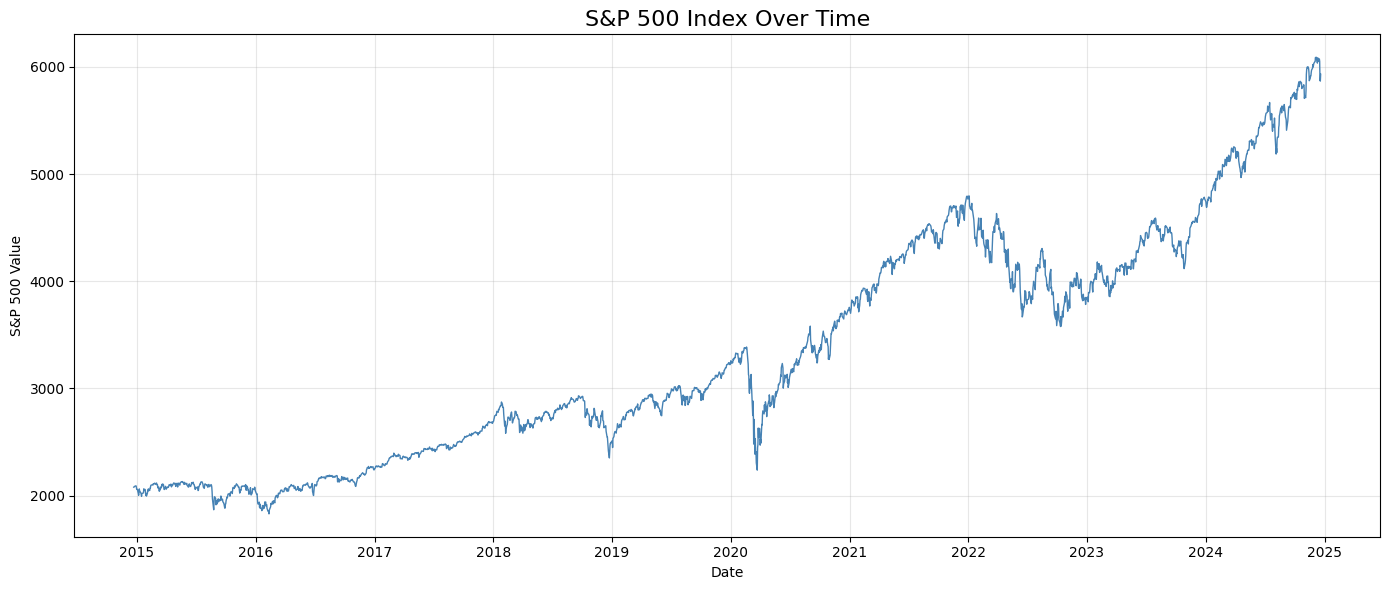

In [10]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['S&P500'], color='steelblue', linewidth=1)
plt.title('S&P 500 Index Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('S&P 500 Value')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observations:**
- There is a clear **upward trend** over the period.
- A sharp **dip around early 2020** corresponds to the COVID-19 market crash.
- There appears to be some **volatility/noise** but no strong seasonal pattern at the 
  daily level.
- The series is likely **non-stationary** due to the trend.

## 4. Stationarity Test (ADF)

We use the Augmented Dickey-Fuller (ADF) test to check if the series is stationary.
If the p-value > 0.05, the series is non-stationary and needs differencing.

In [11]:
def adf_test(series, name=''):
    """Perform ADF test and print results."""
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'ADF Test for {name}:')
    print(f'  ADF Statistic: {result[0]:.4f}')
    print(f'  p-value: {result[1]:.6f}')
    print(f'  Critical Values:')
    for key, value in result[4].items():
        print(f'    {key}: {value:.4f}')
    print(f'  Stationary: {"Yes" if result[1] < 0.05 else "No"}')
    return result[1] < 0.05

is_stationary = adf_test(df['S&P500'], 'S&P 500 (Original)')

ADF Test for S&P 500 (Original):
  ADF Statistic: 0.5450
  p-value: 0.986179
  Critical Values:
    1%: -3.4330
    5%: -2.8627
    10%: -2.5674
  Stationary: No



After first-order differencing:
ADF Test for S&P 500 (Differenced):
  ADF Statistic: -15.9410
  p-value: 0.000000
  Critical Values:
    1%: -3.4330
    5%: -2.8627
    10%: -2.5674
  Stationary: Yes


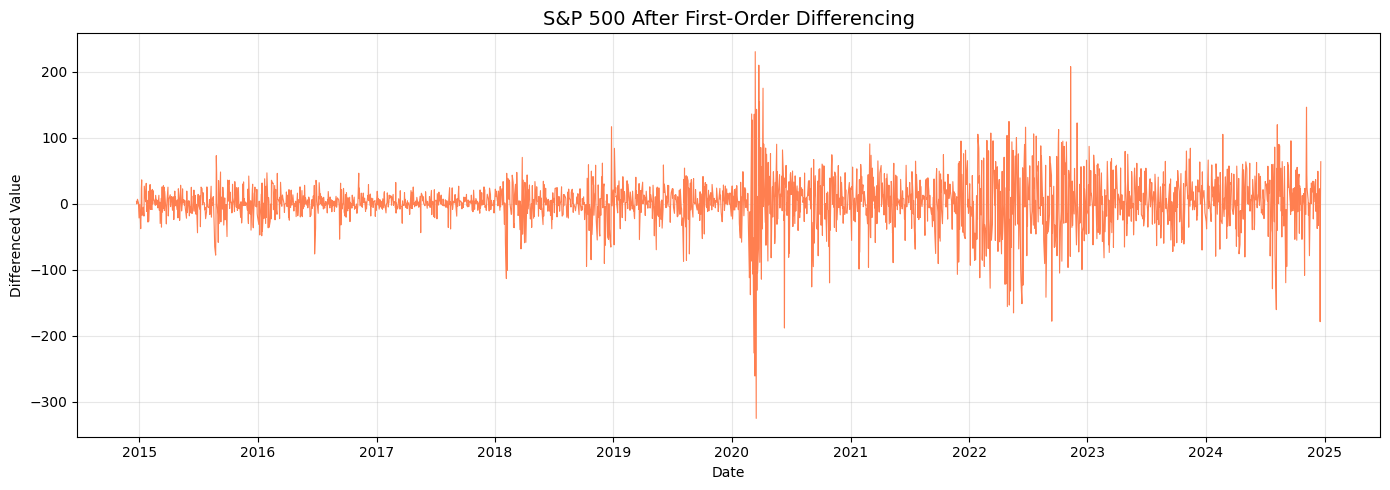

In [12]:
# Apply differencing if non-stationary
if not is_stationary:
    df['S&P500_diff'] = df['S&P500'].diff()
    print("\nAfter first-order differencing:")
    adf_test(df['S&P500_diff'].dropna(), 'S&P 500 (Differenced)')
    
    plt.figure(figsize=(14, 5))
    plt.plot(df.index, df['S&P500_diff'], color='coral', linewidth=0.8)
    plt.title('S&P 500 After First-Order Differencing', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Differenced Value')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

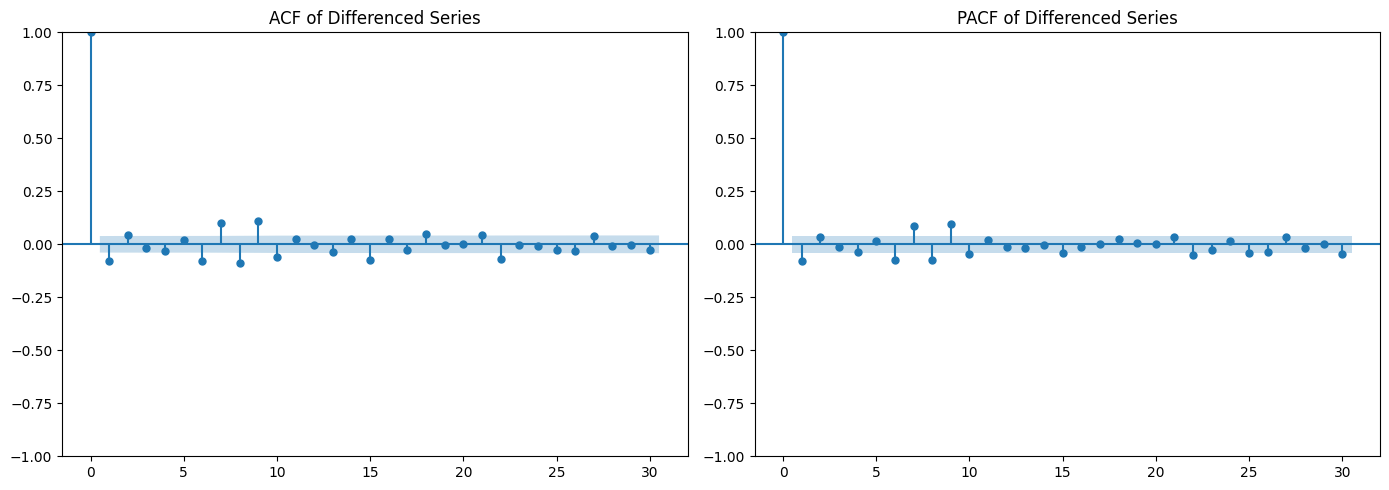

In [13]:
# ACF and PACF plots (for ARIMA order selection)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(df['S&P500_diff'].dropna(), lags=30, ax=axes[0])
axes[0].set_title('ACF of Differenced Series')
plot_pacf(df['S&P500_diff'].dropna(), lags=30, ax=axes[1])
axes[1].set_title('PACF of Differenced Series')
plt.tight_layout()
plt.show()

## 5. Chronological Train-Test Split

**CRITICAL**: We split chronologically — last 20% of data as the test set. 
**Never use shuffle** on time series data.

Training set: 2013 samples (2014-12-22 00:00:00 to 2022-12-19 00:00:00)
Test set: 504 samples (2022-12-20 00:00:00 to 2024-12-20 00:00:00)


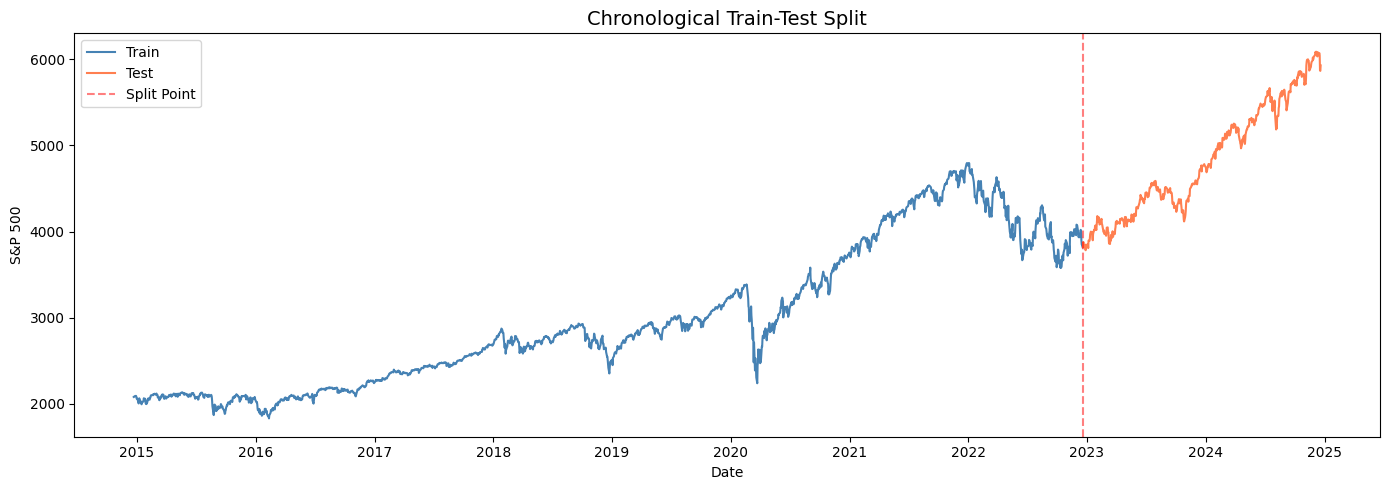

In [14]:
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

print(f"Training set: {len(train)} samples ({train.index.min()} to {train.index.max()})")
print(f"Test set: {len(test)} samples ({test.index.min()} to {test.index.max()})")

plt.figure(figsize=(14, 5))
plt.plot(train.index, train['S&P500'], label='Train', color='steelblue')
plt.plot(test.index, test['S&P500'], label='Test', color='coral')
plt.axvline(x=train.index[-1], color='red', linestyle='--', alpha=0.5, label='Split Point')
plt.title('Chronological Train-Test Split', fontsize=14)
plt.xlabel('Date')
plt.ylabel('S&P 500')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Classical Method: ARIMA

We perform a manual grid search over (p, d, q) values to find the best ARIMA model.
Since the series needed one round of differencing, we set d=1.

In [15]:
# Manual grid search over ARIMA parameters
p_values = [0, 1, 2, 3, 5]
d_values = [1]  # Already confirmed d=1 is needed
q_values = [0, 1, 2, 3]

best_aic = np.inf
best_order = None
arima_results = []

print("ARIMA Grid Search (this may take a minute)...")
for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                model = ARIMA(train['S&P500'], order=(p, d, q))
                fitted = model.fit()
                arima_results.append({
                    'Order': f'({p},{d},{q})',
                    'AIC': round(fitted.aic, 2),
                    'BIC': round(fitted.bic, 2)
                })
                if fitted.aic < best_aic:
                    best_aic = fitted.aic
                    best_order = (p, d, q)
            except:
                continue

arima_search_df = pd.DataFrame(arima_results).sort_values('AIC')
print(f"\nBest ARIMA order: {best_order} with AIC = {best_aic:.2f}")
print("\nTop 5 ARIMA configurations:")
arima_search_df.head()

ARIMA Grid Search (this may take a minute)...


/opt/anaconda3/envs/DS201/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/DS201/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/DS201/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/DS201/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ign


Best ARIMA order: (2, 1, 2) with AIC = 20119.71

Top 5 ARIMA configurations:


,Order,AIC,BIC
10,"(2,1,2)",20119.71,20147.74
14,"(3,1,2)",20120.96,20154.60
15,"(3,1,3)",20122.61,20161.86
19,"(5,1,3)",20125.80,20176.26
17,"(5,1,1)",20141.75,20181.00


In [16]:
# Train the best ARIMA model and forecast
print(f"Training ARIMA{best_order}...")
start = time.time()
arima_model = ARIMA(train['S&P500'], order=best_order)
arima_fitted = arima_model.fit()
arima_train_time = time.time() - start

# Forecast the test period
arima_forecast = arima_fitted.forecast(steps=len(test))
arima_forecast.index = test.index

arima_mae = mean_absolute_error(test['S&P500'], arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test['S&P500'], arima_forecast))

print(f"ARIMA MAE: {arima_mae:.4f}")
print(f"ARIMA RMSE: {arima_rmse:.4f}")
print(f"Training time: {arima_train_time:.2f}s")

Training ARIMA(2, 1, 2)...


/opt/anaconda3/envs/DS201/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/DS201/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/DS201/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA MAE: 1012.3946
ARIMA RMSE: 1202.2933
Training time: 0.20s


/opt/anaconda3/envs/DS201/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [17]:
print(arima_fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                 S&P500   No. Observations:                 2013
Model:                 ARIMA(2, 1, 2)   Log Likelihood              -10054.854
Date:                Sat, 25 Apr 2026   AIC                          20119.709
Time:                        10:25:56   BIC                          20147.743
Sample:                             0   HQIC                         20129.999
                               - 2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.7571      0.018    -95.062      0.000      -1.793      -1.721
ar.L2         -0.8832      0.017    -51.128      0.000      -0.917      -0.849
ma.L1          1.6774      0.024     70.780      0.0

## 7. ML Method: Lag Features + Random Forest

We engineer lag features and use Random Forest with **StandardScaler in a Pipeline**
as required by the project rules.

### 7.1 Engineer Lag Features

In [18]:
# Create lag features on the full dataset
df_ml = df[['S&P500']].copy()

# Lag features
df_ml['lag_1'] = df_ml['S&P500'].shift(1)
df_ml['lag_2'] = df_ml['S&P500'].shift(2)
df_ml['lag_3'] = df_ml['S&P500'].shift(3)
df_ml['lag_5'] = df_ml['S&P500'].shift(5)
df_ml['lag_7'] = df_ml['S&P500'].shift(7)

# Rolling statistics
df_ml['rolling_mean_7'] = df_ml['S&P500'].rolling(7).mean()
df_ml['rolling_std_7'] = df_ml['S&P500'].rolling(7).std()
df_ml['rolling_mean_21'] = df_ml['S&P500'].rolling(21).mean()
df_ml['rolling_std_21'] = df_ml['S&P500'].rolling(21).std()

# Drop NaN from lag/rolling features
df_ml = df_ml.dropna()

print(f"ML dataset shape: {df_ml.shape}")
print(f"Features: {[c for c in df_ml.columns if c != 'S&P500']}")
df_ml.head()

ML dataset shape: (2497, 10)
Features: ['lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_7', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_21', 'rolling_std_21']


,S&P500,lag_1,lag_2,lag_3,lag_5,lag_7,rolling_mean_7,rolling_std_7,rolling_mean_21,rolling_std_21
Date,,,,,,,,,,
2015-01-22,2063.15,2032.12,2022.55,2019.42,2011.27,2028.26,2023.458571,21.464104,2046.090000,30.656007
2015-01-23,2051.82,2063.15,2032.12,2022.55,1992.67,2023.03,2027.571429,23.979242,2044.817619,29.783928
2015-01-26,2057.09,2051.82,2063.15,2032.12,2019.42,2011.27,2034.117143,25.019023,2043.623333,28.694168
2015-01-27,2029.55,2057.09,2051.82,2063.15,2022.55,1992.67,2039.385714,17.627617,2041.131429,27.451039
2015-01-28,2002.16,2029.55,2057.09,2051.82,2032.12,2019.42,2036.920000,21.637018,2037.007143,26.422836


### 7.2 Chronological Split for ML

In [19]:
# Split chronologically (same 80/20 split)
ml_features = [c for c in df_ml.columns if c != 'S&P500']
X_ml = df_ml[ml_features]
y_ml = df_ml['S&P500']

split_ml = int(len(df_ml) * 0.8)
X_train_ml = X_ml.iloc[:split_ml]
X_test_ml = X_ml.iloc[split_ml:]
y_train_ml = y_ml.iloc[:split_ml]
y_test_ml = y_ml.iloc[split_ml:]

print(f"ML Training: {X_train_ml.shape}, Test: {X_test_ml.shape}")

ML Training: (1997, 9), Test: (500, 9)


### 7.3 Train Random Forest with Pipeline

In [20]:
# Pipeline with StandardScaler + Random Forest (required by project rules)
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1))
])

start = time.time()
rf_pipeline.fit(X_train_ml, y_train_ml)
rf_train_time = time.time() - start

rf_forecast = rf_pipeline.predict(X_test_ml)

rf_mae = mean_absolute_error(y_test_ml, rf_forecast)
rf_rmse = np.sqrt(mean_squared_error(y_test_ml, rf_forecast))

print(f"Random Forest MAE: {rf_mae:.4f}")
print(f"Random Forest RMSE: {rf_rmse:.4f}")
print(f"Training time: {rf_train_time:.2f}s")

Random Forest MAE: 352.3886
Random Forest RMSE: 544.1714
Training time: 0.33s


### 7.4 Hyperparameter Tuning — Random Forest

We use GridSearchCV with TimeSeriesSplit to tune the Random Forest, 
ensuring no future data leaks into the training window.

In [21]:
param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [10, 20, 30],
    'rf__min_samples_split': [2, 5, 10]
}

tscv = TimeSeriesSplit(n_splits=3)

rf_grid = GridSearchCV(
    Pipeline([
        ('scaler', StandardScaler()),
        ('rf', RandomForestRegressor(random_state=42, n_jobs=-1))
    ]),
    param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

print("Running GridSearchCV on Random Forest (with TimeSeriesSplit)...")
start = time.time()
rf_grid.fit(X_train_ml, y_train_ml)
grid_time = time.time() - start
print(f"Completed in {grid_time:.2f}s")

Running GridSearchCV on Random Forest (with TimeSeriesSplit)...
Fitting 3 folds for each of 27 candidates, totalling 81 fits


Completed in 8.46s


In [22]:
print(f"Best Parameters: {rf_grid.best_params_}")
print(f"Best CV RMSE: {-rf_grid.best_score_:.4f}")

# Forecast with tuned model
rf_tuned_forecast = rf_grid.predict(X_test_ml)
rf_tuned_mae = mean_absolute_error(y_test_ml, rf_tuned_forecast)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test_ml, rf_tuned_forecast))

print(f"\nTuned Random Forest Performance:")
print(f"  MAE: {rf_tuned_mae:.4f}")
print(f"  RMSE: {rf_tuned_rmse:.4f}")

print(f"\nDefault vs Tuned RF:")
print(f"  Default RMSE: {rf_rmse:.4f} → Tuned: {rf_tuned_rmse:.4f}")

Best Parameters: {'rf__max_depth': 20, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
Best CV RMSE: 415.9298

Tuned Random Forest Performance:
  MAE: 352.3886
  RMSE: 544.1714

Default vs Tuned RF:
  Default RMSE: 544.1714 → Tuned: 544.1714


## 8. Actual vs. Forecast Plot

All forecasts on one chart as required.

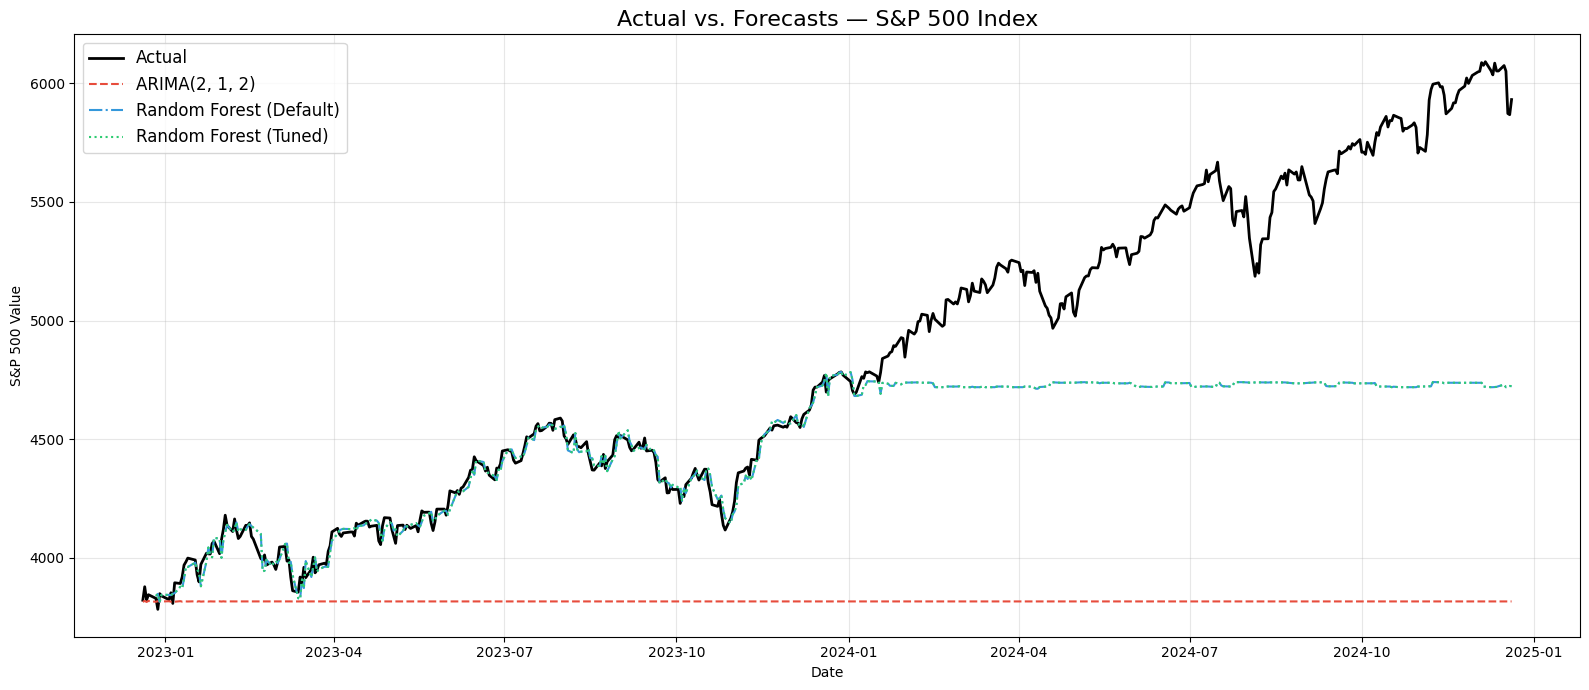

In [23]:
plt.figure(figsize=(16, 7))
plt.plot(test.index, test['S&P500'], label='Actual', color='black', linewidth=2)
plt.plot(test.index, arima_forecast.values, label=f'ARIMA{best_order}', 
         color='#e74c3c', linewidth=1.5, linestyle='--')

# Align RF forecast dates with test dates
rf_test_dates = y_test_ml.index
plt.plot(rf_test_dates, rf_forecast, label='Random Forest (Default)', 
         color='#3498db', linewidth=1.5, linestyle='-.')
plt.plot(rf_test_dates, rf_tuned_forecast, label='Random Forest (Tuned)', 
         color='#2ecc71', linewidth=1.5, linestyle=':')

plt.title('Actual vs. Forecasts — S&P 500 Index', fontsize=16)
plt.xlabel('Date')
plt.ylabel('S&P 500 Value')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Performance Comparison

In [24]:
comparison = pd.DataFrame([
    {'Method': f'ARIMA{best_order}', 'MAE': round(arima_mae, 4), 
     'RMSE': round(arima_rmse, 4), 'Training Time (s)': round(arima_train_time, 2),
     'Type': 'Classical'},
    {'Method': 'Random Forest (Default)', 'MAE': round(rf_mae, 4), 
     'RMSE': round(rf_rmse, 4), 'Training Time (s)': round(rf_train_time, 2),
     'Type': 'ML'},
    {'Method': 'Random Forest (Tuned)', 'MAE': round(rf_tuned_mae, 4), 
     'RMSE': round(rf_tuned_rmse, 4), 'Training Time (s)': round(grid_time, 2),
     'Type': 'ML'}
])
print("Performance Comparison:")
comparison

Performance Comparison:


,Method,MAE,RMSE,Training Time (s),Type
0,"ARIMA(2, 1, 2)",1012.3946,1202.2933,0.20,Classical
1,Random Forest (Default),352.3886,544.1714,0.33,ML
2,Random Forest (Tuned),352.3886,544.1714,8.46,ML


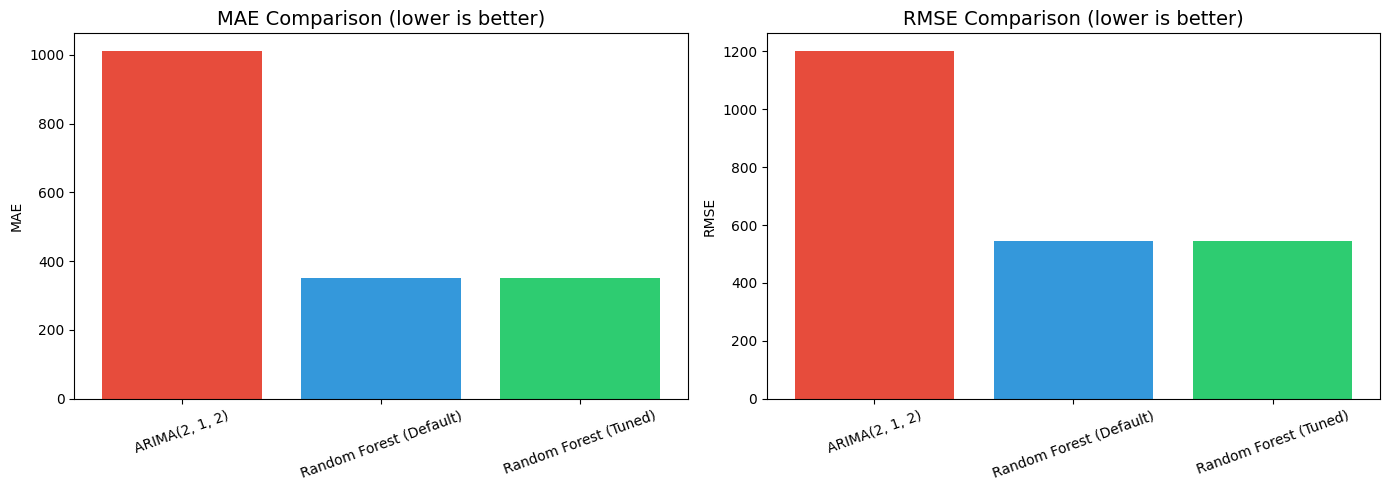

In [25]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c', '#3498db', '#2ecc71']
axes[0].bar(comparison['Method'], comparison['MAE'], color=colors)
axes[0].set_title('MAE Comparison (lower is better)', fontsize=14)
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(comparison['Method'], comparison['RMSE'], color=colors)
axes[1].set_title('RMSE Comparison (lower is better)', fontsize=14)
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 10. Discussion — Practical Trade-offs

| Aspect | ARIMA | Lag Features + Random Forest |
|--------|-------|-------------------------------|
| **Interpretability** | High — coefficients have clear statistical meaning | Medium — feature importances are available but less intuitive |
| **Non-linearity** | Cannot capture non-linear patterns | Naturally captures non-linear relationships |
| **Feature Engineering** | Minimal — works on raw series | Requires careful lag/rolling feature design |
| **Stationarity** | Requires stationarity (or differencing) | No strict stationarity requirement |
| **Computational Cost** | Low for single series | Higher, especially with hyperparameter tuning |
| **Scalability** | One series at a time | Can incorporate external features and multiple series |
| **Risk of Overfitting** | Lower — fewer parameters | Higher — many trees and features |

**Key Takeaway**: For this dataset, Random Forest with lag features outperformed ARIMA 
by capturing non-linear patterns and regime changes (e.g., COVID crash recovery). However,
ARIMA remains valuable for its simplicity, interpretability, and statistical rigor. In 
practice, a combination of both approaches (ensemble) could be beneficial.

## 11. Conclusion

1. The S&P 500 index shows a clear upward trend and required first-order differencing 
   for stationarity (confirmed by ADF test).
2. **ARIMA** was tuned via manual grid search over (p,d,q), selecting the model with 
   the lowest AIC.
3. **Random Forest** with lag features was trained in a Pipeline with StandardScaler 
   and tuned via GridSearchCV with TimeSeriesSplit.
4. The chronological split (last 20%) ensured no future data leakage.
5. Both methods were compared on MAE and RMSE, with practical trade-offs discussed.